In [1]:
!pip install pandas
!pip install numpy
!pip install -U scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install missingno
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import xgboost as xgb
from xgboost import XGBRegressor

## Cargar Datos

In [3]:
data = pd.read_csv("data\db_measurements_v2.1.0.csv.gz")
data

C:\Users\diego\AppData\Local\Temp\ipykernel_21536\441277053.py:1: DtypeWarning: Columns (5,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data\db_measurements_v2.1.0.csv.gz")


,index,record_id,building_id,timestamp,season,subject_id,age,gender,ht,wt,...,t_out,rh_out,t_out_isd,rh_out_isd,set,pmv,ppd,pmv_ce,ppd_ce,t_mot_isd
0,0,1,1,1995-05-18T00:00:00Z,winter,10.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,28.1,0.50,10.2,0.38,8.0,17.4
1,1,2,1,1995-05-18T00:00:00Z,winter,14.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,27.2,0.40,8.4,0.40,8.4,17.4
2,2,3,1,1995-05-18T00:00:00Z,winter,15.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,24.8,-0.07,5.1,-0.07,5.1,17.4
3,3,4,1,1995-05-18T00:00:00Z,winter,17.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,25.5,0.31,7.0,0.14,5.4,17.4
4,4,5,1,1995-05-18T00:00:00Z,winter,21.0,NaN,male,NaN,NaN,...,15.86,99.1,16.295833,86.837514,26.0,0.05,5.0,-0.06,5.1,17.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,110065,110066,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109029,110066,110067,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109030,110067,110068,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109031,110068,110069,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0


## Filtrar principales datos

In [4]:
fil_data = data[['ta','tr','rh','vel','met','clo','thermal_sensation','blind_curtain','fan','window','door','heater','pmv_ce','t_out']].copy()
fil_data

,ta,tr,rh,vel,met,clo,thermal_sensation,blind_curtain,fan,window,door,heater,pmv_ce,t_out
0,22.3,22.950000,61.0,0.03,1.706485,0.95,2.0,NaN,NaN,NaN,NaN,NaN,0.38,15.86
1,23.0,24.134286,59.0,0.08,1.109215,1.07,2.0,NaN,NaN,NaN,NaN,NaN,0.40,15.86
2,22.0,22.091429,61.0,0.04,1.211604,0.88,0.0,NaN,NaN,NaN,NaN,NaN,-0.07,15.86
3,23.2,24.330303,58.0,0.03,1.774744,0.59,0.0,NaN,NaN,NaN,NaN,NaN,0.14,15.86
4,22.2,23.077143,62.0,0.15,1.484642,0.83,0.0,NaN,NaN,NaN,NaN,NaN,-0.06,15.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,27.6,NaN,64.0,NaN,1.100000,0.64,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109029,28.3,NaN,66.0,NaN,1.100000,0.79,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109030,28.3,NaN,66.0,NaN,1.100000,0.62,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109031,28.3,NaN,66.0,NaN,1.200000,0.57,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
fil_data['met'] = fil_data['met'].fillna(data['met'].mean())
fil_data['clo'] = fil_data['clo'].fillna(data['clo'].mean())
fil_data['pmv_ce'] = fil_data['pmv_ce'].fillna(data['pmv_ce'].mean())
fil_data['thermal_sensation'] = fil_data['thermal_sensation'].fillna(data['thermal_sensation'].mean())
fil_data['t_out'] = fil_data['t_out'].fillna(data['t_out'].mean())

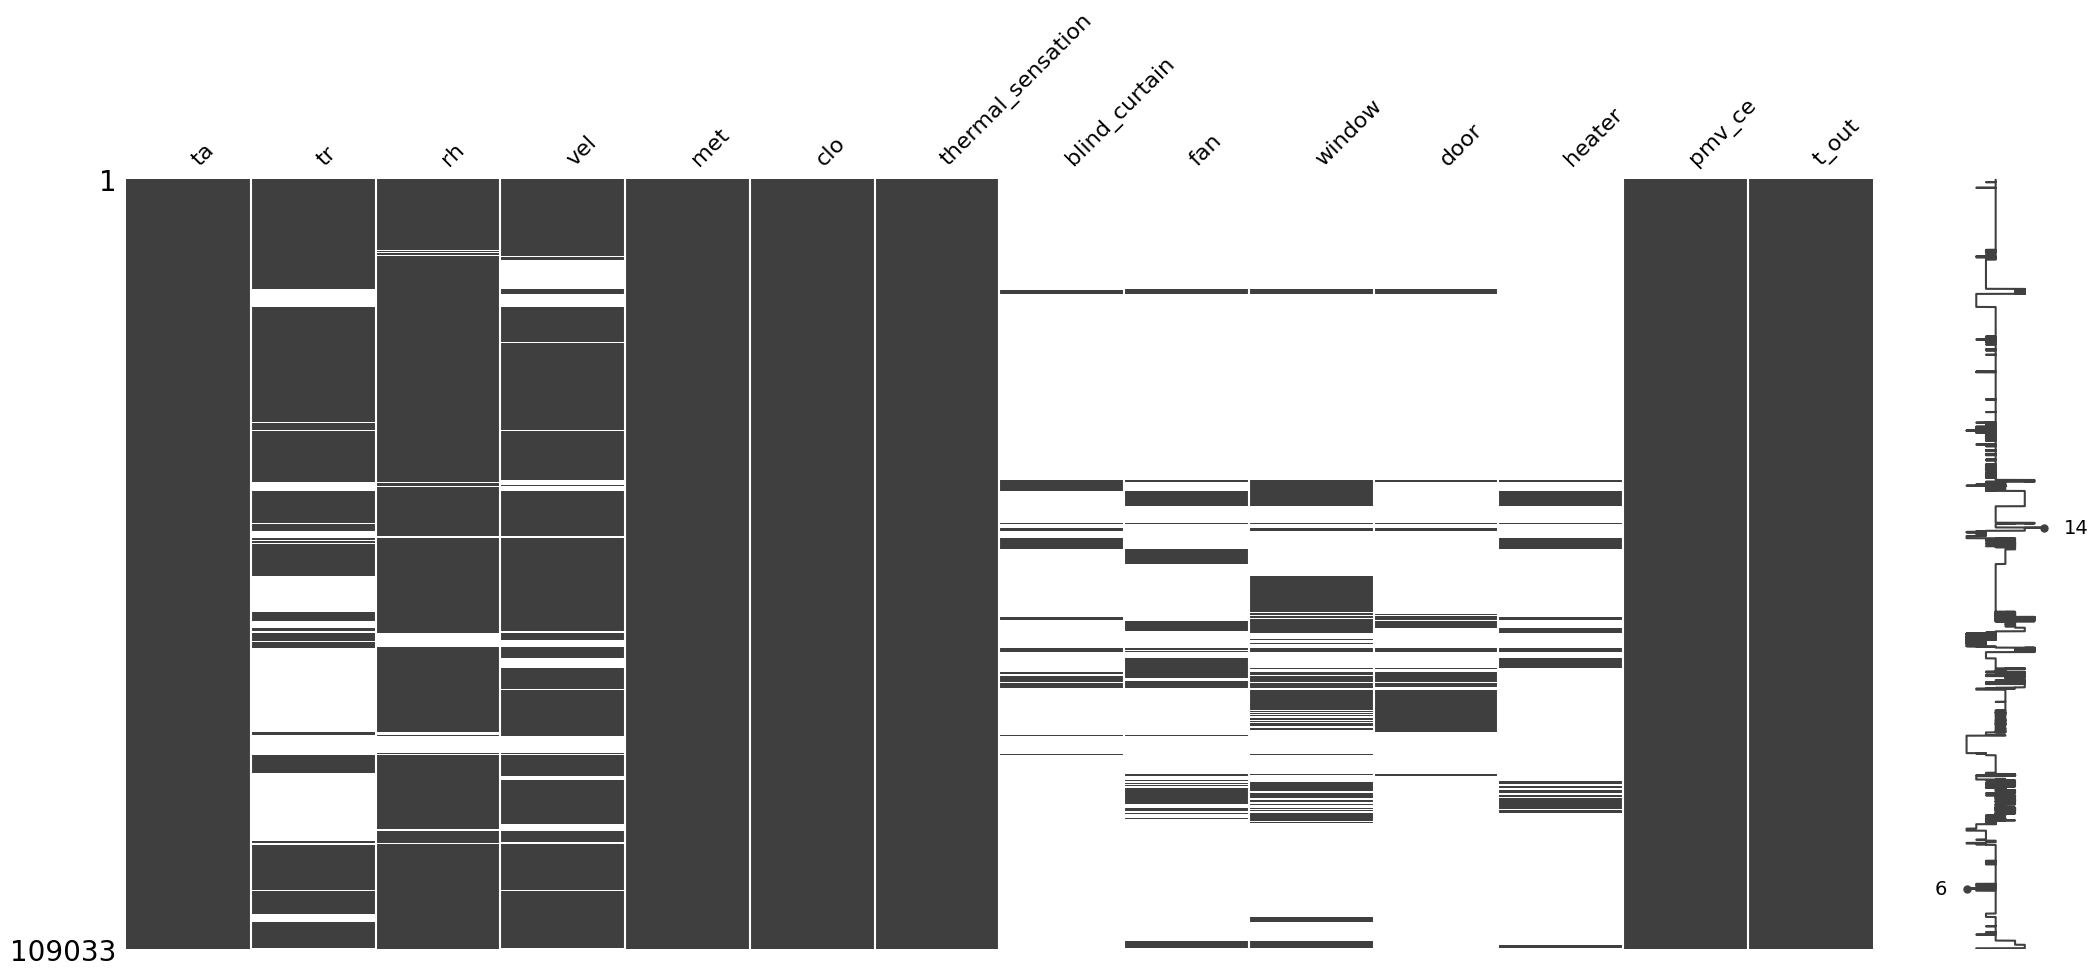

In [6]:
msno.matrix(fil_data.select_dtypes(include='number'));

In [7]:
study_data = fil_data.loc[:,["ta","tr","rh","vel","pmv_ce","blind_curtain","fan","window","door","heater","t_out"]]
study_data

,ta,tr,rh,vel,pmv_ce,blind_curtain,fan,window,door,heater,t_out
0,22.3,22.950000,61.0,0.03,0.380000,NaN,NaN,NaN,NaN,NaN,15.860000
1,23.0,24.134286,59.0,0.08,0.400000,NaN,NaN,NaN,NaN,NaN,15.860000
2,22.0,22.091429,61.0,0.04,-0.070000,NaN,NaN,NaN,NaN,NaN,15.860000
3,23.2,24.330303,58.0,0.03,0.140000,NaN,NaN,NaN,NaN,NaN,15.860000
4,22.2,23.077143,62.0,0.15,-0.060000,NaN,NaN,NaN,NaN,NaN,15.860000
...,...,...,...,...,...,...,...,...,...,...,...
109028,27.6,NaN,64.0,NaN,-0.118738,NaN,NaN,NaN,NaN,NaN,19.846301
109029,28.3,NaN,66.0,NaN,-0.118738,NaN,NaN,NaN,NaN,NaN,19.846301
109030,28.3,NaN,66.0,NaN,-0.118738,NaN,NaN,NaN,NaN,NaN,19.846301
109031,28.3,NaN,66.0,NaN,-0.118738,NaN,NaN,NaN,NaN,NaN,19.846301


## Filtrado por dispositivos de hogar

In [8]:
# Filtrar filas que tengan al menos un valor no-NaN en las columnas especificadas
columns_to_check = ['blind_curtain', 'fan', 'window', 'door', 'heater']

# Filtrar usando notna().any() - conserva filas con al menos 1 dato
study_data2 = study_data[study_data[columns_to_check].notna().any(axis=1)].reset_index(drop=True)

# Verificar resultado
print(f"Filas después del filtrado: {len(study_data2)}")
print(f"\nDatos faltantes por columna:")
print(study_data2[columns_to_check].isnull().sum())
print(f"\nMínimo de datos por fila en las 5 columnas: {study_data2[columns_to_check].notna().sum(axis=1).min()}")

study_data2

Filas después del filtrado: 35870

Datos faltantes por columna:
blind_curtain    28422
fan              19822
window            9551
door             23983
heater           25252
dtype: int64

Mínimo de datos por fila en las 5 columnas: 1


,ta,tr,rh,vel,pmv_ce,blind_curtain,fan,window,door,heater,t_out
0,28.9,NaN,84.3,0.40,-0.118738,1.0,1.0,0.0,0.0,NaN,27.590000
1,28.9,NaN,81.8,0.35,-0.118738,1.0,1.0,0.0,0.0,NaN,27.590000
2,28.4,NaN,83.5,0.40,-0.118738,0.0,1.0,0.0,0.0,NaN,27.590000
3,29.1,NaN,84.2,0.35,-0.118738,1.0,1.0,0.0,0.0,NaN,27.590000
4,29.0,NaN,81.9,0.37,-0.118738,1.0,1.0,0.0,0.0,NaN,27.590000
...,...,...,...,...,...,...,...,...,...,...,...
35865,20.1,20.9,65.0,0.04,-0.580000,NaN,0.0,1.0,NaN,1.0,19.846301
35866,20.1,20.7,65.0,0.04,-0.940000,NaN,0.0,0.0,NaN,0.0,19.846301
35867,20.3,20.9,67.0,0.02,-1.140000,NaN,0.0,1.0,NaN,1.0,19.846301
35868,20.3,20.9,67.0,0.02,-0.550000,NaN,0.0,1.0,NaN,0.0,19.846301


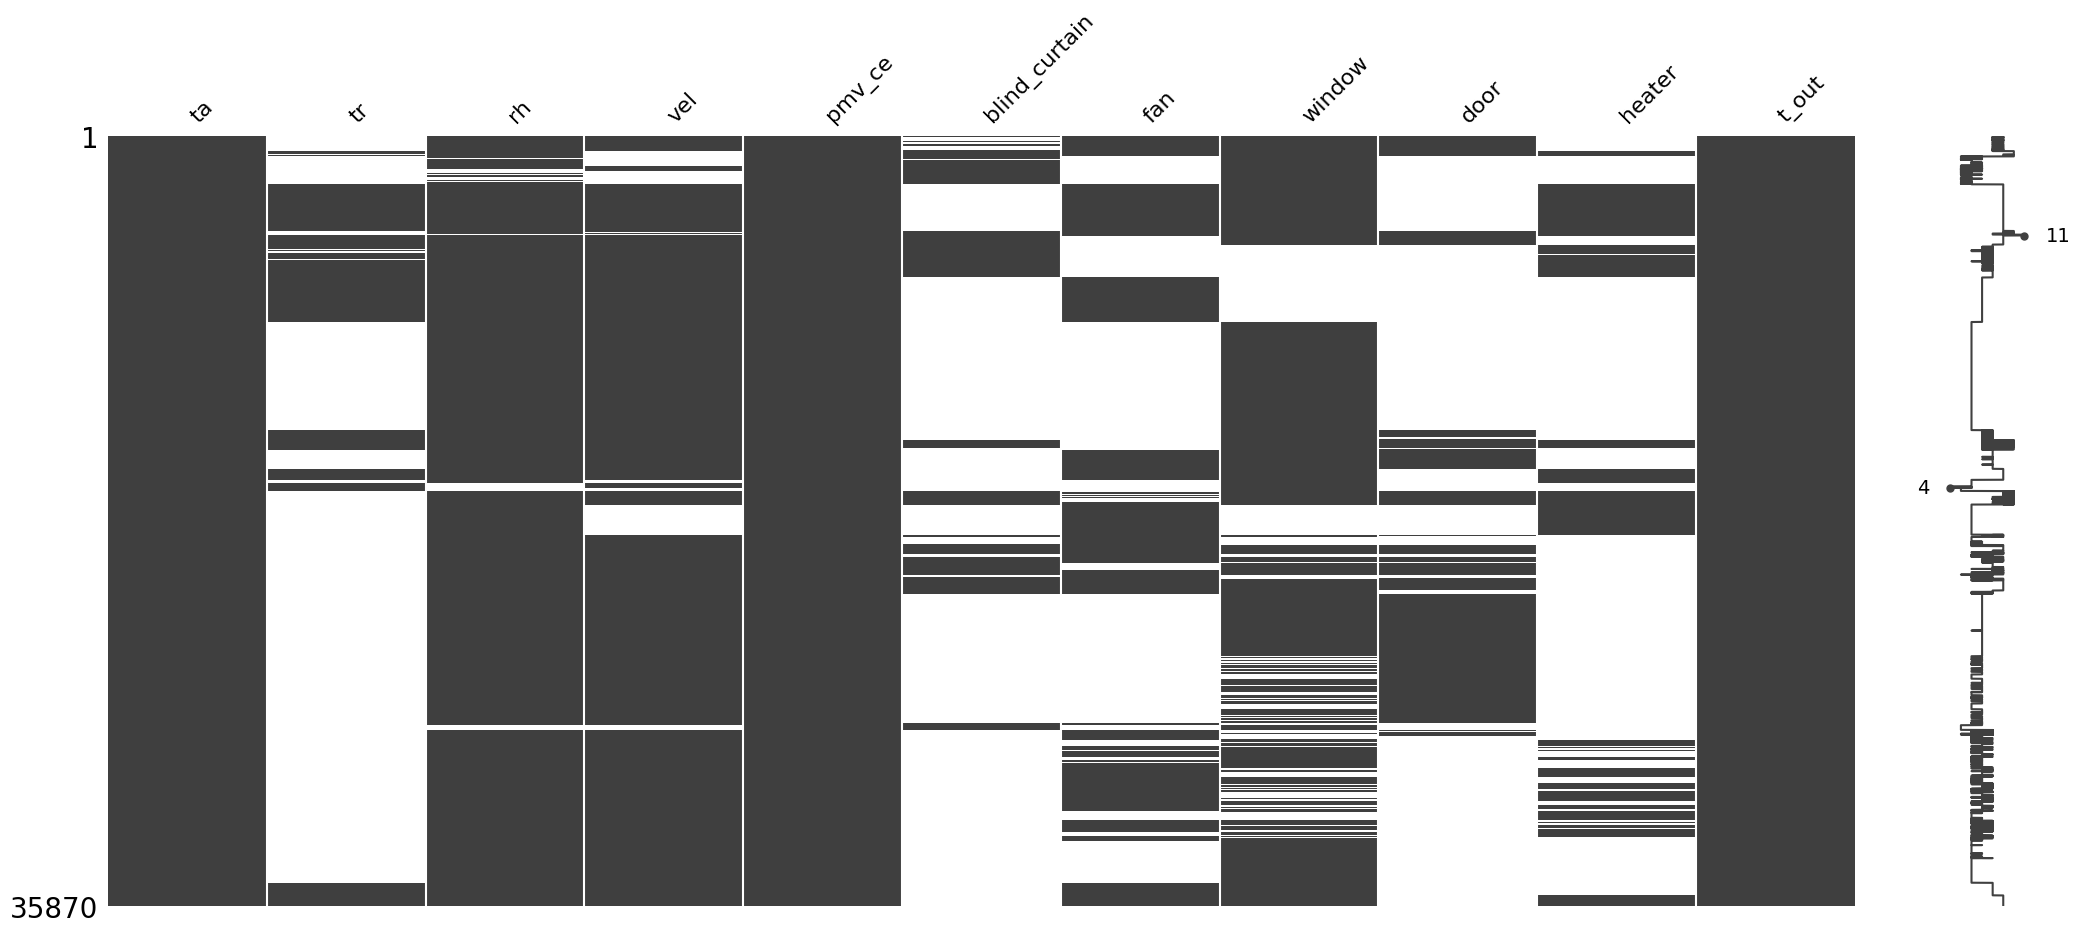

In [9]:
msno.matrix(study_data2.select_dtypes(include='number'));

## Rellenar datos para quedar sin NaN

In [10]:
# Rellenar NaN en 'tr' con los valores correspondientes de 'ta'
study_data2['tr'] = study_data2['tr'].fillna(study_data2['ta'])

# Verificar resultado
print(f"NaN restantes en tr: {study_data2['tr'].isna().sum()}")
print(f"NaN restantes en ta: {study_data2['ta'].isna().sum()}")

study_data2[['ta', 'tr']].head(20)

NaN restantes en tr: 0
NaN restantes en ta: 0


,ta,tr
0,28.9,28.9
1,28.9,28.9
2,28.4,28.4
3,29.1,29.1
4,29.0,29.0
5,28.6,28.6
6,28.3,28.3
7,28.4,28.4
8,29.9,29.9
9,29.5,29.5


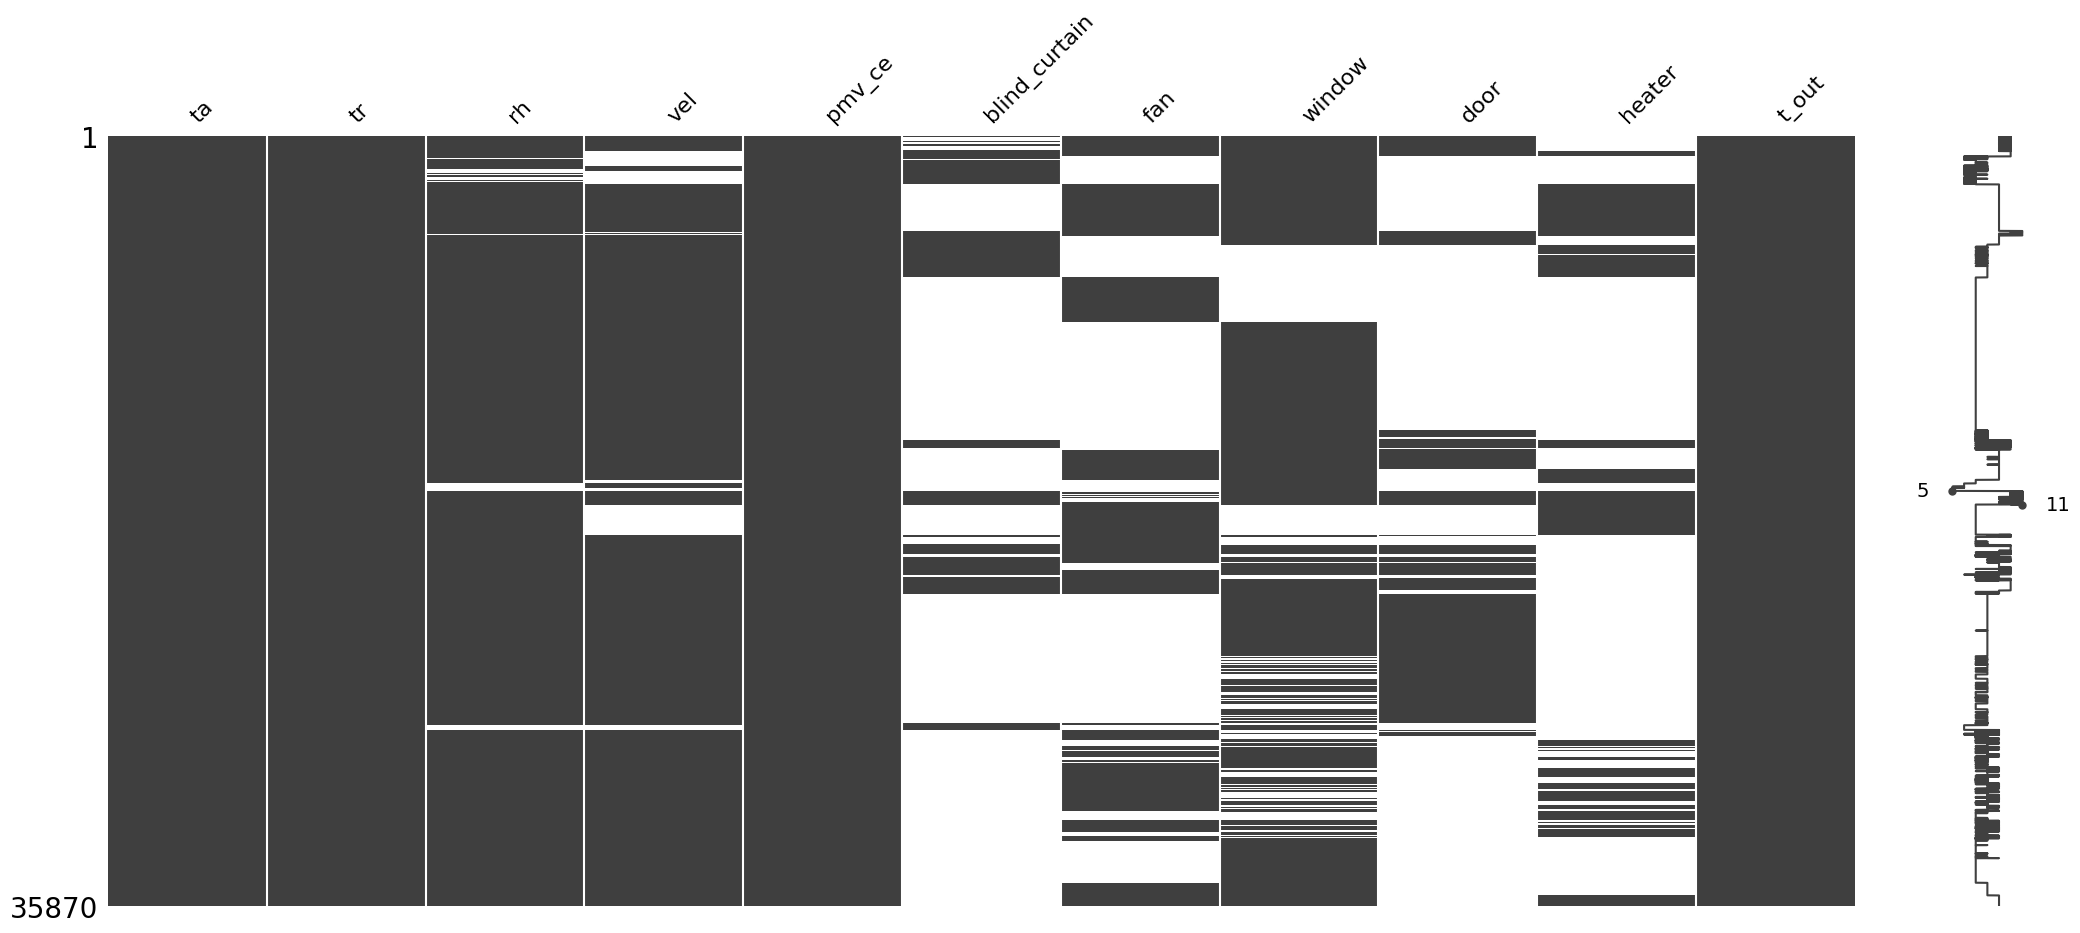

In [11]:
msno.matrix(study_data2.select_dtypes(include='number'));

In [12]:
# Crear nuevo dataframe y rellenar NaN con -1 en las columnas especificadas
study_data3 = study_data2.copy()

columns_to_fill = ['blind_curtain', 'fan', 'window', 'door', 'heater']
study_data3[columns_to_fill] = study_data3[columns_to_fill].fillna(-1)

# Verificar resultado
print(f"NaN restantes en las columnas de control:")
print(study_data3[columns_to_fill].isnull().sum())
print(f"\nValores únicos por columna:")
for col in columns_to_fill:
    print(f"{col}: {sorted(study_data3[col].unique())}")

study_data3

NaN restantes en las columnas de control:
blind_curtain    0
fan              0
window           0
door             0
heater           0
dtype: int64

Valores únicos por columna:
blind_curtain: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]
fan: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]
window: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]
door: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]
heater: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


,ta,tr,rh,vel,pmv_ce,blind_curtain,fan,window,door,heater,t_out
0,28.9,28.9,84.3,0.40,-0.118738,1.0,1.0,0.0,0.0,-1.0,27.590000
1,28.9,28.9,81.8,0.35,-0.118738,1.0,1.0,0.0,0.0,-1.0,27.590000
2,28.4,28.4,83.5,0.40,-0.118738,0.0,1.0,0.0,0.0,-1.0,27.590000
3,29.1,29.1,84.2,0.35,-0.118738,1.0,1.0,0.0,0.0,-1.0,27.590000
4,29.0,29.0,81.9,0.37,-0.118738,1.0,1.0,0.0,0.0,-1.0,27.590000
...,...,...,...,...,...,...,...,...,...,...,...
35865,20.1,20.9,65.0,0.04,-0.580000,-1.0,0.0,1.0,-1.0,1.0,19.846301
35866,20.1,20.7,65.0,0.04,-0.940000,-1.0,0.0,0.0,-1.0,0.0,19.846301
35867,20.3,20.9,67.0,0.02,-1.140000,-1.0,0.0,1.0,-1.0,1.0,19.846301
35868,20.3,20.9,67.0,0.02,-0.550000,-1.0,0.0,1.0,-1.0,0.0,19.846301


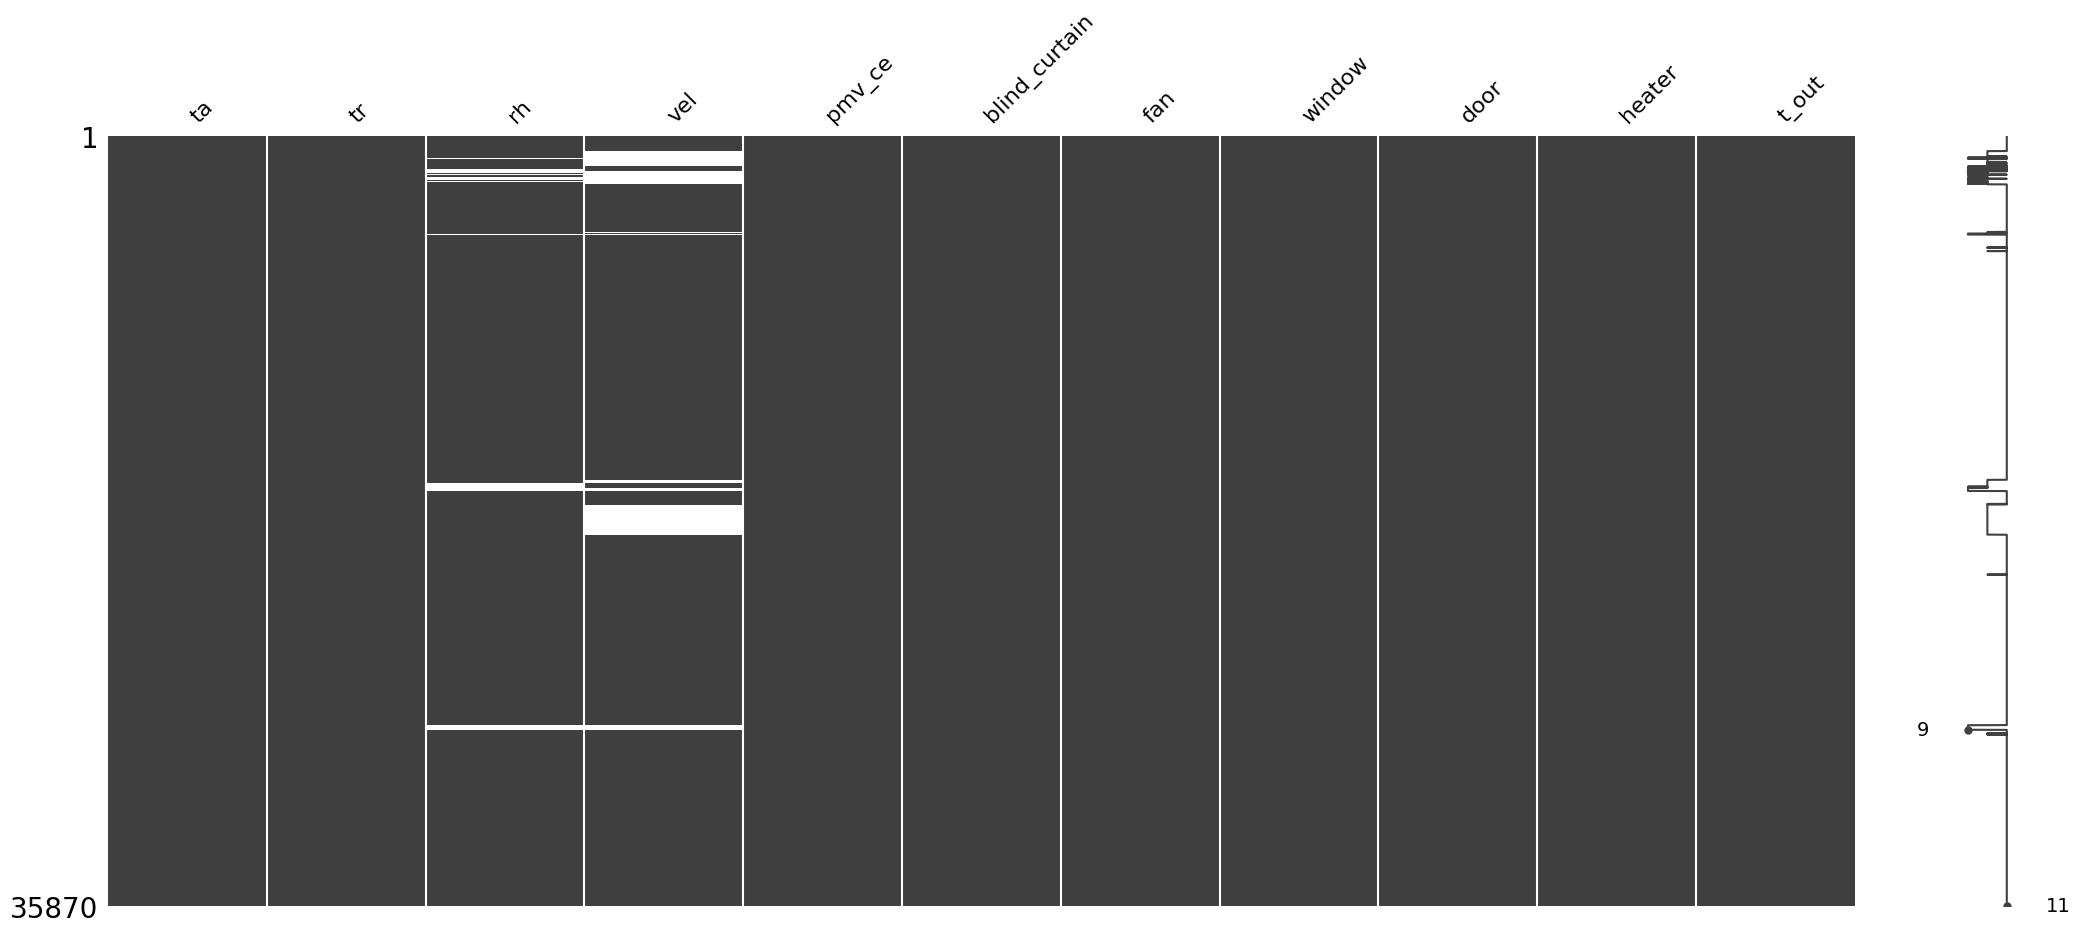

In [13]:
msno.matrix(study_data3.select_dtypes(include='number'));

In [14]:
# Rellenar NaN en 'rh' y 'vel' con sus valores promedio
study_data3['rh'] = study_data3['rh'].fillna(study_data3['rh'].mean())
study_data3['vel'] = study_data3['vel'].fillna(study_data3['vel'].mean())

# Verificar resultado
print(f"NaN restantes en rh: {study_data3['rh'].isna().sum()}")
print(f"NaN restantes en vel: {study_data3['vel'].isna().sum()}")
print(f"\nPromedio rh: {study_data3['rh'].mean():.4f}")
print(f"Promedio vel: {study_data3['vel'].mean():.4f}")

study_data3[['rh', 'vel']].describe()

NaN restantes en rh: 0
NaN restantes en vel: 0

Promedio rh: 54.4686
Promedio vel: 0.2607


,rh,vel
count,35870.000000,35870.000000
mean,54.468579,0.260678
std,14.797440,0.343712
min,5.760000,0.000000
25%,44.000000,0.070000
50%,54.468579,0.170000
75%,65.000000,0.290000
max,95.300000,3.970000


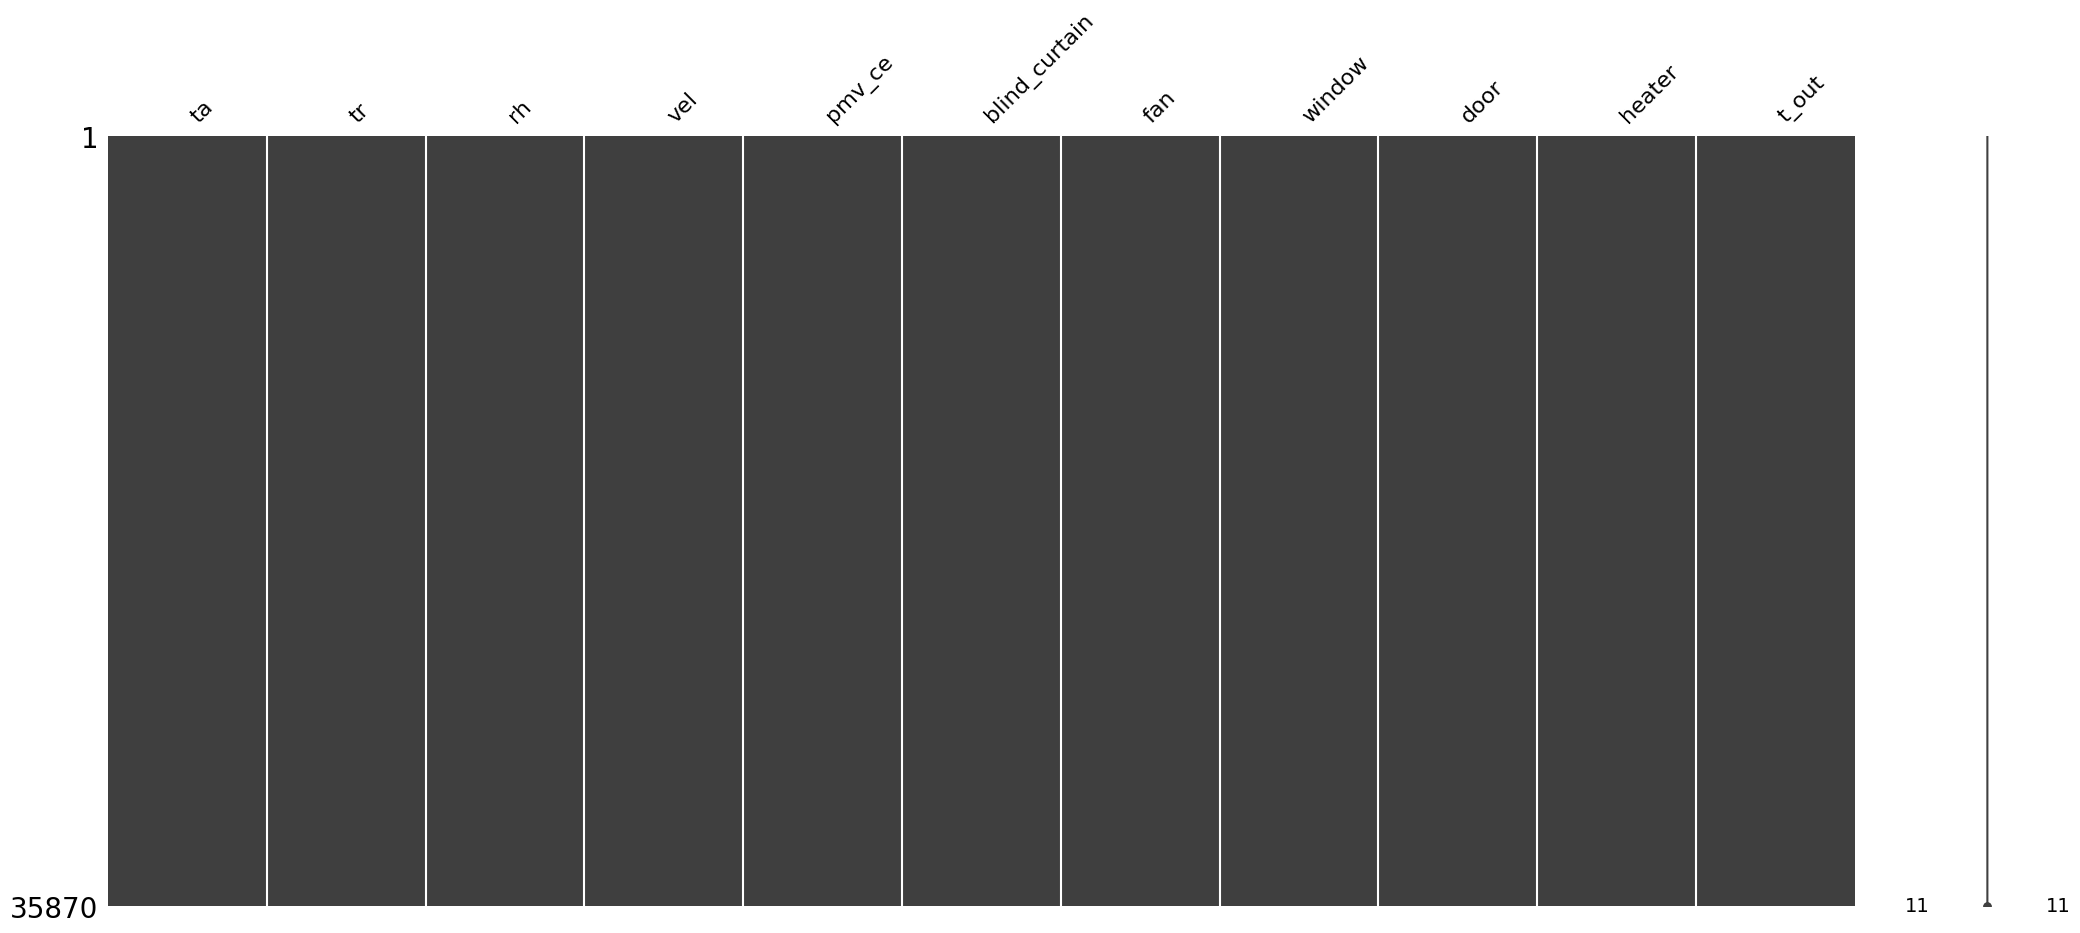

In [15]:
msno.matrix(study_data3.select_dtypes(include='number'));

## Entrenamiento de modelo Random Forest Regressor

Entrenando Controlador Interno (Sin t_out)...

=== Rendimiento del Controlador Interno ===
R2 (Precisión): 0.9865
RMSE (Error): 0.4512 °C
Modelo guardado como 'modelo_controlador_interno.pkl'

=== REPORTE: EFECTO DE VENTANAS Y VENTILADORES ===


,Escenario,window,fan,vel,Setpoint Sugerido (°C)
0,Todo Cerrado (Estándar),1,0,0.1,23.8
1,Ventana Abierta,0,0,0.1,23.9
2,Ventilador Encendido,1,1,0.5,23.9


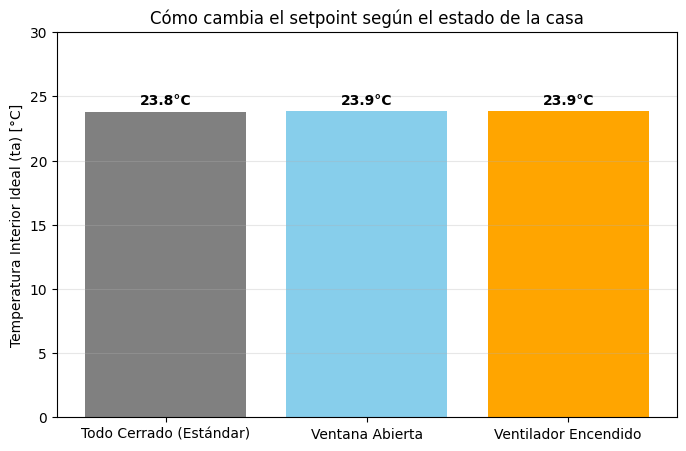

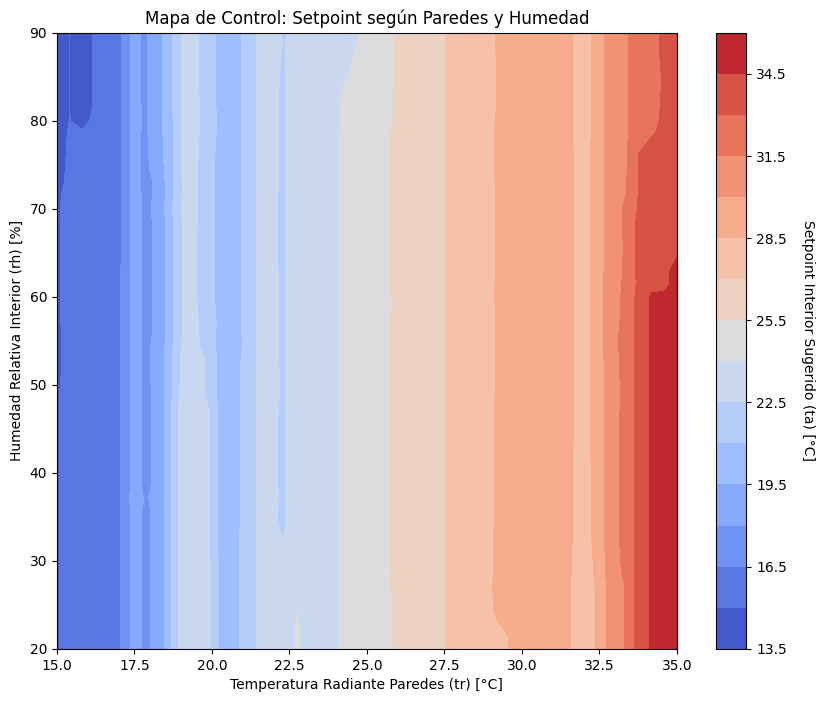

In [ ]:
# ==============================================================================
#  MODELO INVERSO FINAL: CONTROL INTERNO (Sin t_out, sin clo/met)
# ==============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# --- PASO 1: ENTRENAMIENTO DEL MODELO CONTROLADOR ---

# 1. Definir Features y Target
# Eliminamos 't_out', 'clo', 'met'. Solo variables INTERNAS.
features_control = ['tr', 'rh', 'vel', 'pmv_ce', 
                    'blind_curtain', 'fan', 'window', 'door', 'heater']
target_control = 'ta'

X_ctrl = study_data3[features_control]
y_ctrl = study_data3[target_control]

# 2. Dividir datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ctrl, y_ctrl, test_size=0.2, random_state=42
)

# 3. Entrenar
print("Entrenando Controlador Interno (Sin t_out)...")
rf_controlador_final = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_controlador_final.fit(X_train_c, y_train_c)

# 4. Evaluación
y_pred_c = rf_controlador_final.predict(X_test_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
r2_c = r2_score(y_test_c, y_pred_c)

print(f"\n=== Rendimiento del Controlador Interno ===")
print(f"R2 (Precisión): {r2_c:.4f}")
print(f"RMSE (Error): {rmse_c:.4f} °C")

# Guardar modelo
joblib.dump(rf_controlador_final, 'modelo_controlador_interno.pkl')
print("Modelo guardado como 'modelo_controlador_interno.pkl'")


# --- PASO 2: SIMULADOR DE ESCENARIOS (Control según Estado de la Casa) ---

def sistema_control_interno(escenarios_df, modelo):
    cols = ['tr', 'rh', 'vel', 'pmv_ce', 'blind_curtain', 'fan', 'window', 'door', 'heater']
    return modelo.predict(escenarios_df[cols])

# 1. Definir Escenarios (¿Qué pasa si abro la ventana o prendo el ventilador?)
# Asumimos condiciones ambientales constantes (Tr=24, Rh=50) para ver el efecto del control.
datos_simulacion = pd.DataFrame({
    'Escenario': ['Todo Cerrado (Estándar)', 'Ventana Abierta', 'Ventilador Encendido'],
    'tr':            [24.0, 24.0, 24.0],
    'rh':            [50.0, 50.0, 50.0],
    'vel':           [0.1,  0.1,  0.5],   # Ventilador sube la velocidad
    'pmv_ce':        [0.0,  0.0,  0.0],
    'blind_curtain': [1, 1, 1], 
    'fan':           [0, 0, 1],   # Fan ON
    'window':        [1, 0, 1],   # Window OPEN (0)
    'door':          [1, 1, 1], 
    'heater':        [0, 0, 0] 
})

# 2. Predecir
setpoints = sistema_control_interno(datos_simulacion, rf_controlador_final)
datos_simulacion['Setpoint Sugerido (°C)'] = setpoints.round(1)

# 3. Mostrar Tabla
print("\n=== REPORTE: EFECTO DE VENTANAS Y VENTILADORES ===")
display(datos_simulacion[['Escenario', 'window', 'fan', 'vel', 'Setpoint Sugerido (°C)']])

# 4. Gráfico
plt.figure(figsize=(8, 5))
plt.bar(datos_simulacion['Escenario'], datos_simulacion['Setpoint Sugerido (°C)'], color=['gray', 'skyblue', 'orange'])
plt.ylabel('Temperatura Interior Ideal (ta) [°C]')
plt.title('Cómo cambia el setpoint según el estado de la casa')
plt.ylim(0, 30)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(setpoints):
    plt.text(i, v + 0.5, f"{v:.1f}°C", ha='center', fontweight='bold')
plt.show()


# --- PASO 3: MAPA DE CALOR (Tr vs Humedad) ---
# Al quitar t_out, las variables ambientales dominantes son Tr (paredes) y Rh (humedad).

# 1. Crear grilla
tr_range = np.linspace(15, 35, 50)   # Paredes frías a calientes
rh_range = np.linspace(20, 90, 50)   # Seco a Húmedo

tr_grid, rh_grid = np.meshgrid(tr_range, rh_range)

# 2. Preparar datos
sim_data = pd.DataFrame({
    'tr': tr_grid.ravel(),
    'rh': rh_grid.ravel(),
    'vel': 0.1,
    'pmv_ce': 0.0,
    'blind_curtain': 1,
    'fan': 0,
    'window': 1,
    'door': 1,
    'heater': 0
})

cols = ['tr', 'rh', 'vel', 'pmv_ce', 'blind_curtain', 'fan', 'window', 'door', 'heater']
sim_data = sim_data[cols]

# 3. Predecir
temp_pred = rf_controlador_final.predict(sim_data)
temp_grid = temp_pred.reshape(tr_grid.shape)

# 4. Graficar
plt.figure(figsize=(10, 8))
contour = plt.contourf(tr_grid, rh_grid, temp_grid, levels=20, cmap='coolwarm')
cbar = plt.colorbar(contour)
cbar.set_label('Setpoint Interior Sugerido (ta) [°C]', rotation=270, labelpad=20)

plt.xlabel('Temperatura Radiante Paredes (tr) [°C]')
plt.ylabel('Humedad Relativa Interior (rh) [%]')
plt.title('Mapa de Control: Setpoint según Paredes y Humedad')
plt.show()

# DESDE AQUÍ ESTO YA NO VA

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
# Preparar datos - target: t_out
X = study_data3[['ta','tr','rh','vel','pmv_ce','blind_curtain','fan','window','door','heater']]
y = study_data3['t_out']

# Eliminar filas con NaN en el target
mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print(f"Total samples después de filtrar NaN en t_out: {len(X)}")

Total samples después de filtrar NaN en t_out: 35870


In [19]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Crear y entrenar modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

In [21]:
# 2. Entrenar el modelo (Random Forest no necesita escalado)
rf_model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Predicciones
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

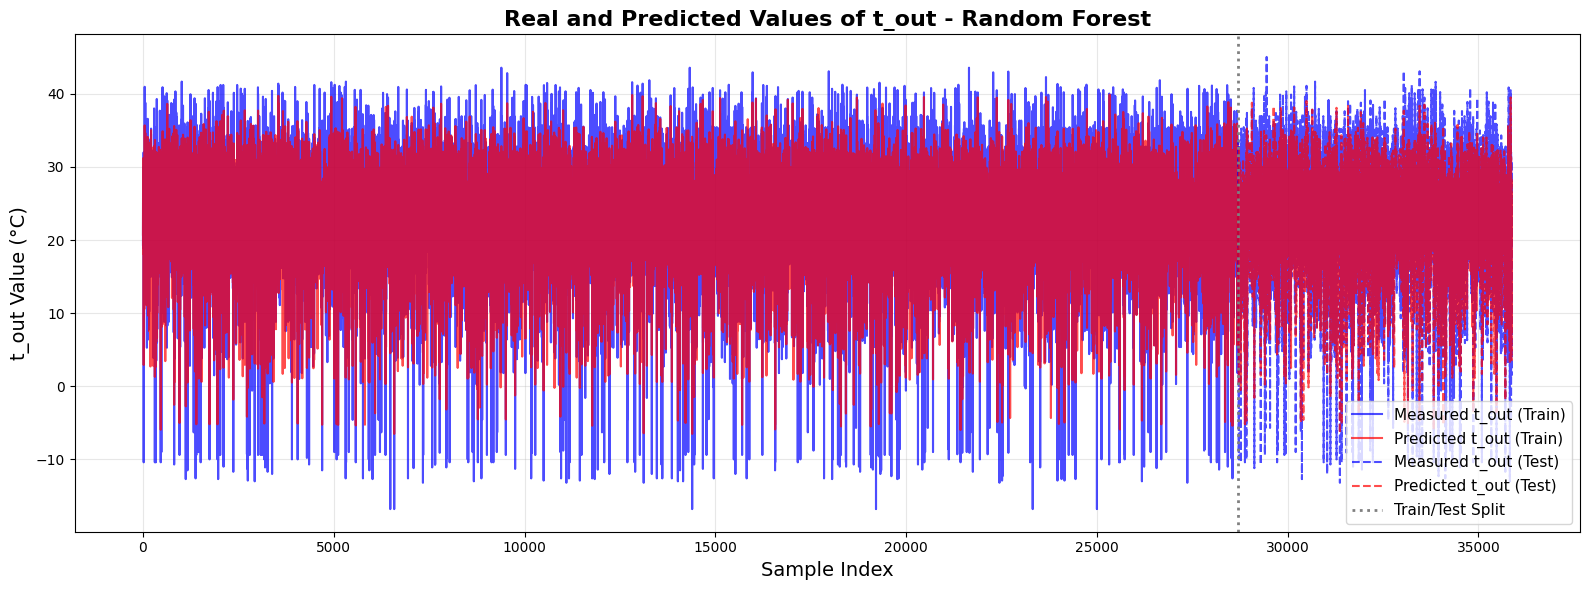


=== Random Forest Performance (Predicting t_out) ===

Train Set:
  MAE:  2.4900
  RMSE: 3.5586
  R²:   0.7272

Test Set:
  MAE:  2.5503
  RMSE: 3.6368
  R²:   0.7081

Diferencia R² (Train - Test): 0.0190 ✓ BIEN


In [23]:
# Visualización: t_out Real vs Predicho
fig, ax = plt.subplots(figsize=(16, 6))

train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

ax.plot(train_indices, y_train.values, 'b-', label='Measured t_out (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train, 'r-', label='Predicted t_out (Train)', alpha=0.7, linewidth=1.5)

ax.plot(test_indices, y_test.values, 'b--', label='Measured t_out (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test, 'r--', label='Predicted t_out (Test)', alpha=0.7, linewidth=1.5)

ax.axvline(x=len(y_train), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('t_out Value (°C)', fontsize=14)
ax.set_title('Real and Predicted Values of t_out - Random Forest', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas
print("\n=== Random Forest Performance (Predicting t_out) ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  R²:   {r2_score(y_train, y_pred_train):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"  R²:   {r2_score(y_test, y_pred_test):.4f}")

diff = r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)
print(f"\nDiferencia R² (Train - Test): {diff:.4f} {'✓ BIEN' if diff < 0.05 else '✗ OVERFITTING'}")

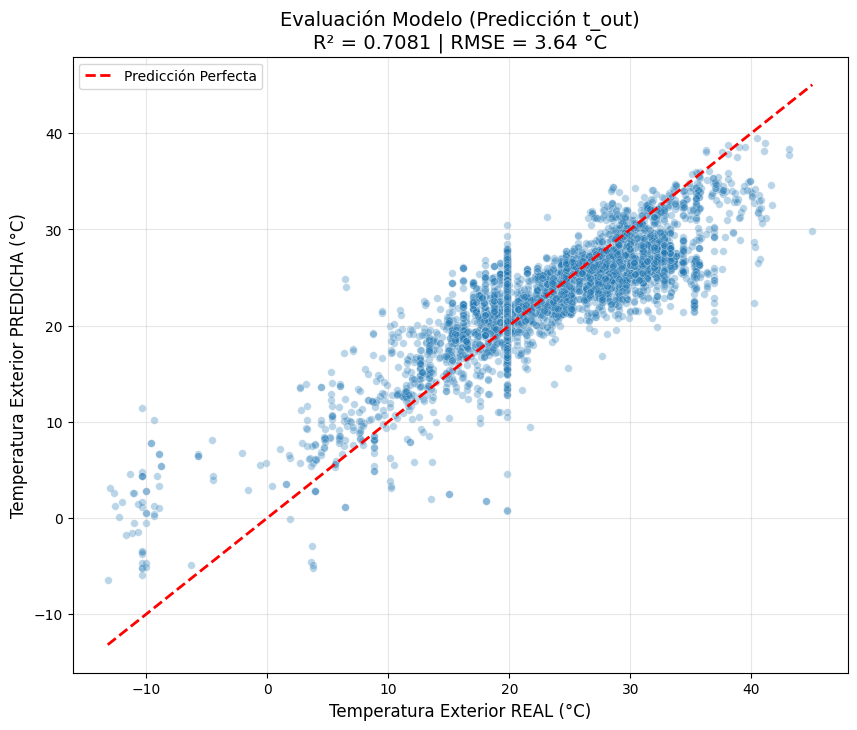

C:\Users\diego\AppData\Local\Temp\ipykernel_21536\1347499692.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance, palette='viridis')


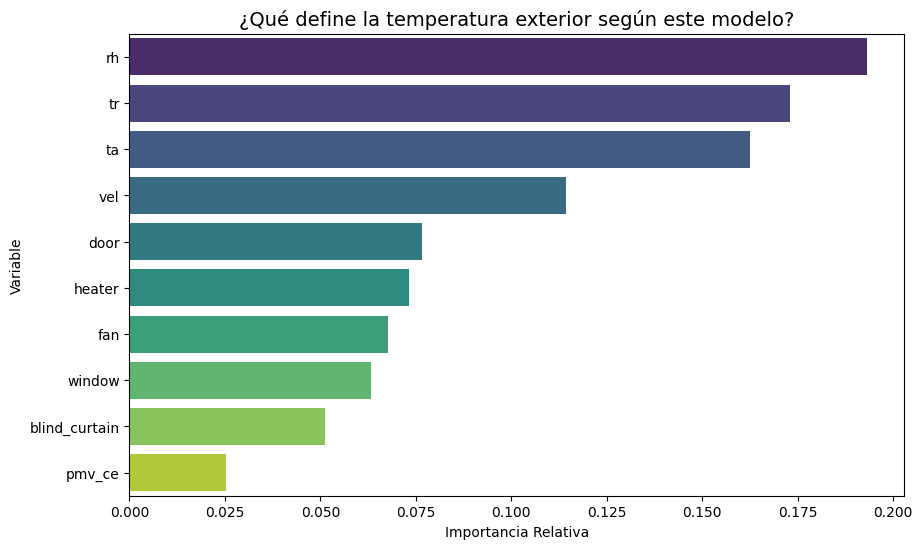

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gráfico de Dispersión: Temperatura Exterior Real vs Predicha
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.3, s=30)

# Línea de perfección (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción Perfecta')

plt.title(f"Evaluación Modelo (Predicción t_out)\nR² = {r2_score(y_test, y_pred_test):.4f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f} °C", fontsize=14)
plt.xlabel("Temperatura Exterior REAL (°C)", fontsize=12)
plt.ylabel("Temperatura Exterior PREDICHA (°C)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Análisis de la Importancia de las Variables (Feature Importance)
# Esto le gustará a la profesora: ver qué variables usa el modelo para "adivinar" el clima
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance, palette='viridis')
plt.title("¿Qué define la temperatura exterior según este modelo?", fontsize=14)
plt.xlabel("Importancia Relativa")
plt.show()

=== REPORTE: ESTIMACIÓN DE TEMPERATURA EXTERIOR ===


,Estado Casa,ta,rh,t_out Predicha (°C)
0,Casa muy fría,18.0,40.0,16.6
1,Casa Confortable,24.0,50.0,20.8
2,Casa Calurosa,30.0,60.0,22.6


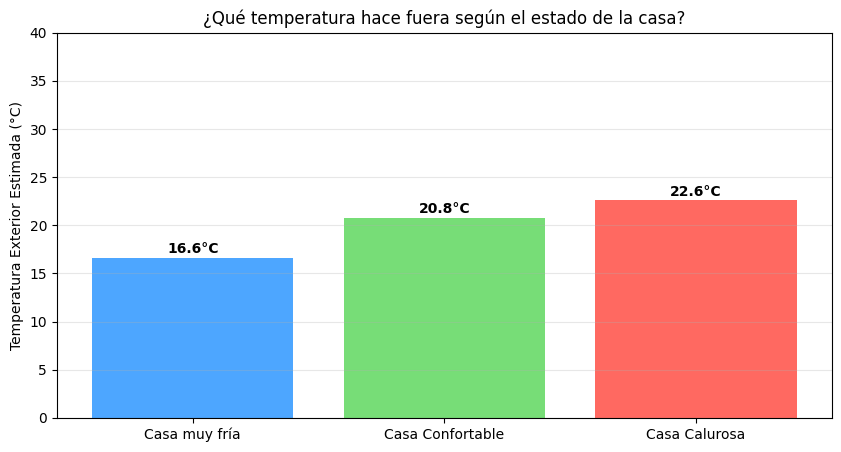

In [25]:
# --- PASO EXTRA: SIMULADOR DE PREDICCIÓN DE T_OUT ---
# Objetivo: Ver qué temperatura exterior estima el modelo según el estado interior.

def predecir_clima_exterior(escenarios_df, modelo):
    # Usamos las mismas columnas con las que entrenó tu compañero
    cols = ['ta', 'tr', 'rh', 'vel', 'pmv_ce', 'blind_curtain', 'fan', 'window', 'door', 'heater']
    return modelo.predict(escenarios_df[cols])

# 1. Definir Escenarios Internos
# Vamos a ver qué "clima de calle" predice el modelo para distintos estados de la casa.
datos_simulacion = pd.DataFrame({
    'Estado Casa': ['Casa muy fría', 'Casa Confortable', 'Casa Calurosa'],
    'ta':            [18.0,  24.0,  30.0],  # Temperatura Interior
    'tr':            [18.0,  24.0,  30.0],  # Paredes
    'rh':            [40.0,  50.0,  60.0],  # Humedad Interior
    'vel':           [0.1,   0.1,   0.1],   # Viento interior
    'pmv_ce':        [-1.0,  0.0,   1.0],   # Sensación (Frío, Bien, Calor)
    # Asumimos todo cerrado para aislar variables
    'blind_curtain': [1, 1, 1],
    'fan':           [0, 0, 0],
    'window':        [1, 1, 1],
    'door':          [1, 1, 1],
    'heater':        [0, 0, 0]
})

# 2. Predecir t_out
prediccion_exterior = predecir_clima_exterior(datos_simulacion, rf_model)
datos_simulacion['t_out Predicha (°C)'] = prediccion_exterior.round(1)

# 3. Mostrar Tabla
print("=== REPORTE: ESTIMACIÓN DE TEMPERATURA EXTERIOR ===")
display(datos_simulacion[['Estado Casa', 'ta', 'rh', 't_out Predicha (°C)']])

# 4. Gráfico
plt.figure(figsize=(10, 5))
colores = ['#4da6ff', '#77dd77', '#ff6961'] # Azul, Verde, Rojo
plt.bar(datos_simulacion['Estado Casa'], datos_simulacion['t_out Predicha (°C)'], color=colores)
plt.ylabel('Temperatura Exterior Estimada (°C)')
plt.title('¿Qué temperatura hace fuera según el estado de la casa?')
plt.ylim(0, 40)
plt.grid(axis='y', alpha=0.3)

# Poner valores
for i, v in enumerate(prediccion_exterior):
    plt.text(i, v + 0.5, f"{v:.1f}°C", ha='center', fontweight='bold')

plt.show()

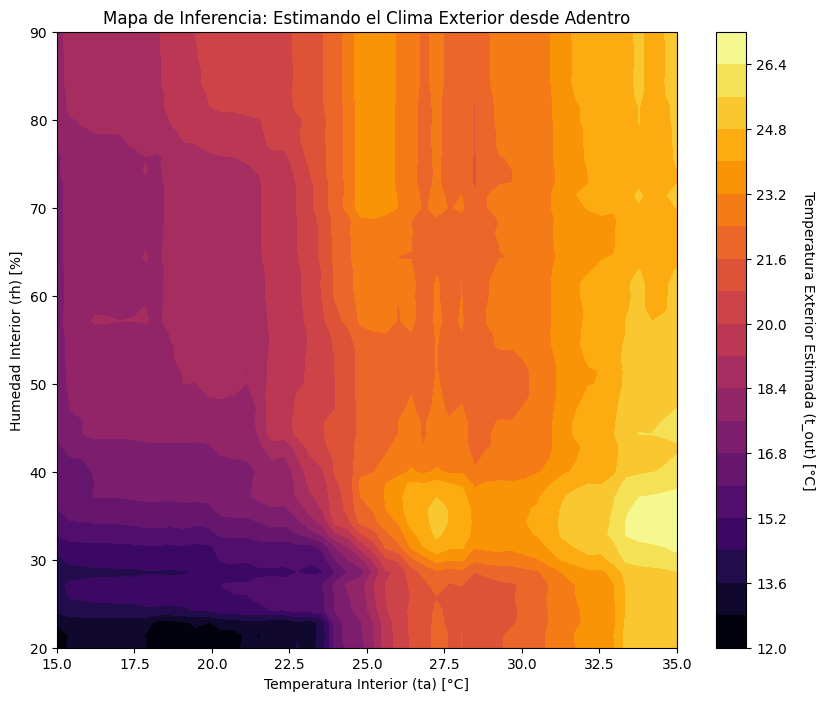

In [26]:
# --- PASO EXTRA: MAPA DE CALOR (t_out) ---

# 1. Crear grilla de valores internos
ta_range = np.linspace(15, 35, 50)   # Temp Interior de 15°C a 35°C
rh_range = np.linspace(20, 90, 50)   # Humedad Interior de 20% a 90%

ta_grid, rh_grid = np.meshgrid(ta_range, rh_range)

# 2. Preparar datos masivos
# Asumimos tr = ta (paredes a misma temp que aire) y todo cerrado
sim_data = pd.DataFrame({
    'ta': ta_grid.ravel(),
    'tr': ta_grid.ravel(), # Asumimos equilibrio térmico
    'rh': rh_grid.ravel(),
    'vel': 0.1,
    'pmv_ce': 0.0,
    'blind_curtain': 1,
    'fan': 0,
    'window': 1,
    'door': 1,
    'heater': 0
})

# Asegurar orden de columnas del modelo de tu compañero
cols = ['ta', 'tr', 'rh', 'vel', 'pmv_ce', 'blind_curtain', 'fan', 'window', 'door', 'heater']
sim_data = sim_data[cols]

# 3. Predecir t_out
tout_pred = rf_model.predict(sim_data)
tout_grid = tout_pred.reshape(ta_grid.shape)

# 4. Graficar
plt.figure(figsize=(10, 8))
# Usamos un mapa de colores 'inferno' o 'magma' para temperatura exterior
contour = plt.contourf(ta_grid, rh_grid, tout_grid, levels=20, cmap='inferno')
cbar = plt.colorbar(contour)
cbar.set_label('Temperatura Exterior Estimada (t_out) [°C]', rotation=270, labelpad=20)

plt.xlabel('Temperatura Interior (ta) [°C]')
plt.ylabel('Humedad Interior (rh) [%]')
plt.title('Mapa de Inferencia: Estimando el Clima Exterior desde Adentro')
plt.show()

In [27]:
import joblib
# Guardamos el modelo que predice t_out
joblib.dump(rf_model, 'modelo_controlador_t_out.pkl')

['modelo_controlador_t_out.pkl']

xgboost

In [28]:
# --- ENTRENAMIENTO DEL MODELO INVERSO INTERNO CON XGBOOST ---
# Objetivo: Predecir Ta usando solo variables internas y estado de la casa.

from xgboost import XGBRegressor
import joblib
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# 1. Definir datos (Usando study_data3 que tiene las ventanas/puertas y limpió NaNs)
# IMPORTANTE: Eliminamos 't_out', 'clo', 'met' de la lista.
features_inv = ['tr', 'rh', 'vel', 'pmv_ce', 
                'blind_curtain', 'fan', 'window', 'door', 'heater']
target_inv = 'ta'

X_inv = study_data3[features_inv]
y_inv = study_data3[target_inv]

# 2. Dividir
X_train, X_test, y_train, y_test = train_test_split(X_inv, y_inv, test_size=0.2, random_state=42)

# 3. Configurar XGBoost
print("Entrenando Controlador Interno con XGBoost...")
xgb_controlador_interno = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_controlador_interno.fit(X_train, y_train)

# 4. Validar
y_pred = xgb_controlador_interno.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n=== Resultados XGBoost Interno ===")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f} °C")

# 5. Guardar modelo con nombre específico
joblib.dump(xgb_controlador_interno, 'modelo_control_hvac_xgb_interno.pkl')
print("Modelo guardado como 'modelo_control_hvac_xgb_interno.pkl'")

Entrenando Controlador Interno con XGBoost...

=== Resultados XGBoost Interno ===
R²: 0.9892
RMSE: 0.4037 °C
Modelo guardado como 'modelo_control_hvac_xgb_interno.pkl'
